In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import spearmanr

In [6]:
df = pd.read_csv(r"C:\Users\anant\Desktop\Disease_symptom_and_patient_profile_dataset.csv")
df

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
...,...,...,...,...,...,...,...,...,...,...
344,Stroke,Yes,No,Yes,No,80,Female,High,High,Positive
345,Stroke,Yes,No,Yes,No,85,Male,High,High,Positive
346,Stroke,Yes,No,Yes,No,85,Male,High,High,Positive
347,Stroke,Yes,No,Yes,No,90,Female,High,High,Positive


In [8]:
df.duplicated().sum()

49

In [10]:
df.drop_duplicates(inplace = True)
df

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
5,Eczema,Yes,No,No,No,25,Female,Normal,Normal,Positive
...,...,...,...,...,...,...,...,...,...,...
341,Tonsillitis,Yes,Yes,Yes,No,70,Female,High,High,Positive
342,Williams Syndrome,No,No,Yes,No,70,Female,Normal,Normal,Positive
343,Stroke,Yes,No,Yes,No,80,Female,High,High,Positive
345,Stroke,Yes,No,Yes,No,85,Male,High,High,Positive


In [12]:
df.duplicated().sum()

0

In [14]:
df.describe()

,Age
count,300.000000
mean,45.756667
std,12.596548
min,19.000000
25%,35.000000
50%,45.000000
75%,55.000000
max,90.000000


In [16]:
df["Disease"].value_counts()

Disease
Asthma                            16
Osteoporosis                      12
Stroke                            11
Hypertension                      10
Migraine                          10
                                  ..
Fibromyalgia                       1
Eating Disorders (Anorexia,...     1
Chickenpox                         1
Rabies                             1
Williams Syndrome                  1
Name: count, Length: 116, dtype: int64

In [18]:
plt.bar(dfs , 

SyntaxError: incomplete input (2371243742.py, line 1)

In [20]:
df.groupby(["Disease"],group_keys = True)[["Age","Blood Pressure"]].apply(lambda x : x.sort_values(by=["Age","Blood Pressure"],ascending = True)) 

Age Blood Pressure
Disease                                              
Acne                          112   40         Normal
Allergic Rhinitis             11    29         Normal
                              55    35         Normal
                              97    38            Low
                              160   45           High
...                                ...            ...
Urinary Tract Infection (UTI) 49    30         Normal
                              74    35           High
                              310   65           High
Williams Syndrome             342   70         Normal
Zika Virus                    177   45           High

[300 rows x 2 columns]

In [22]:
df.shape

(300, 10)

In [24]:
df["Disease"]

0              Influenza
1            Common Cold
2                 Eczema
3                 Asthma
5                 Eczema
             ...        
341          Tonsillitis
342    Williams Syndrome
343               Stroke
345               Stroke
347               Stroke
Name: Disease, Length: 300, dtype: object

In [26]:
df["Gender"].value_counts()

Gender
Female    152
Male      148
Name: count, dtype: int64

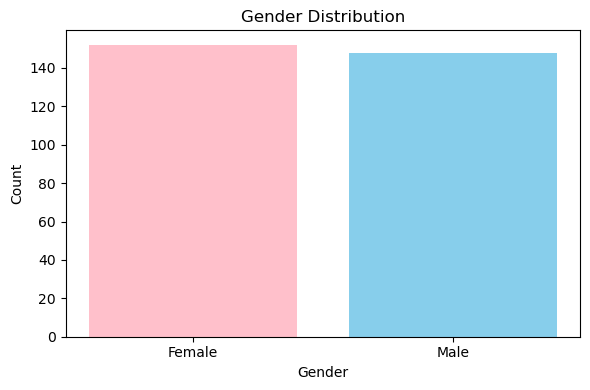

In [28]:
import matplotlib.pyplot as plt

# Count gender occurrences
gender_counts = df["Gender"].value_counts()

# Plot
plt.figure(figsize=(6, 4))
plt.bar(gender_counts.index, gender_counts.values, color=["Pink", "Skyblue"])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



DISEASE PREVALENCE

In [31]:
df["Disease"].value_counts()


Disease
Asthma                            16
Osteoporosis                      12
Stroke                            11
Hypertension                      10
Migraine                          10
                                  ..
Fibromyalgia                       1
Eating Disorders (Anorexia,...     1
Chickenpox                         1
Rabies                             1
Williams Syndrome                  1
Name: count, Length: 116, dtype: int64

In [33]:
dfs = df["Disease"].value_counts().head(10)

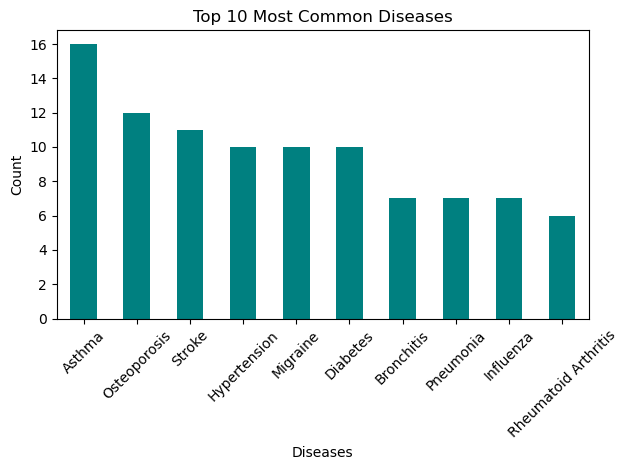

In [35]:
dfs.plot(kind = "bar", color = "teal")
plt.title("Top 10 Most Common Diseases")
plt.xlabel("Diseases")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.tight_layout()

C:\Users\anant\AppData\Local\Temp\ipykernel_11964\1685751300.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["Gender", "Age Group", "Disease"]).size().reset_index(name="Count")
C:\Users\anant\AppData\Local\Temp\ipykernel_11964\1685751300.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=filtered, x="Disease", y="Count", hue="Gender", ci=None)


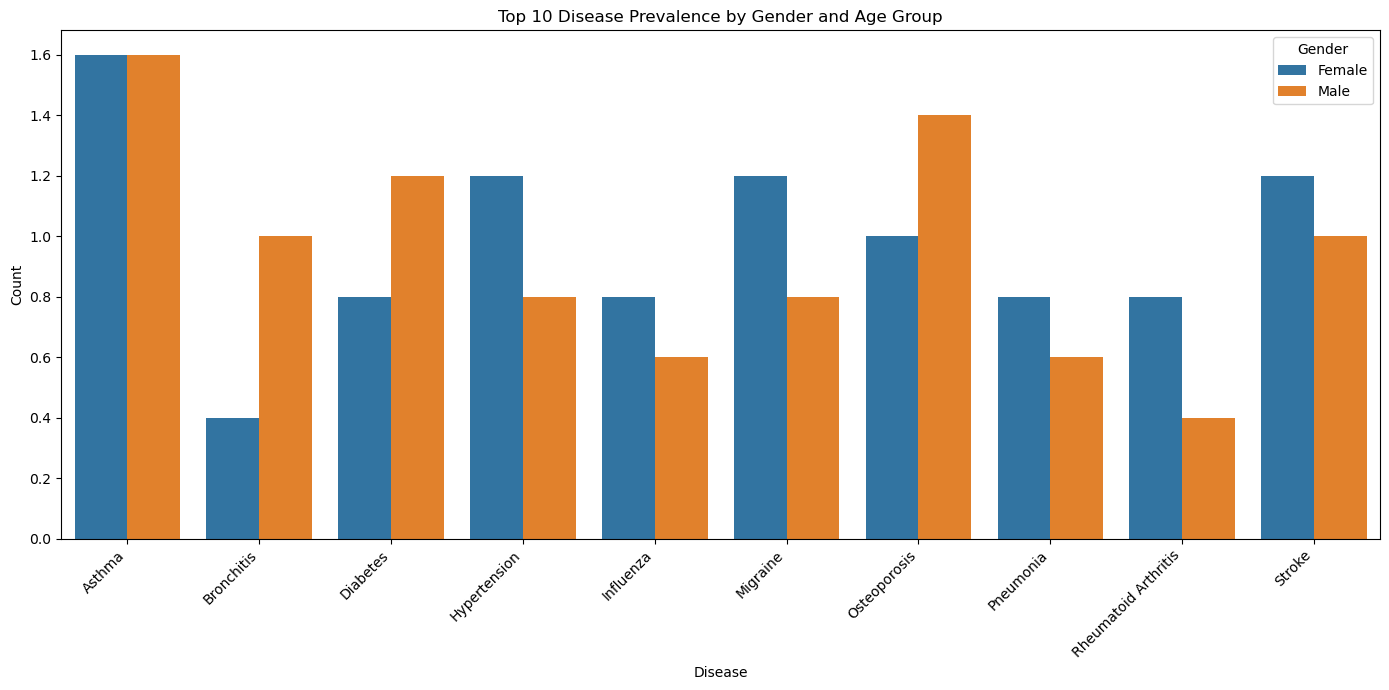

In [37]:
bins = [0, 18, 35, 50, 65, 100]
labels = ["0–18", "19–35", "36–50", "51–65", "66+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Group by Gender, Age Group, and Disease
grouped = df.groupby(["Gender", "Age Group", "Disease"]).size().reset_index(name="Count")

# Filter to top 10 diseases for clarity
top_diseases = df["Disease"].value_counts().nlargest(10).index
filtered = grouped[grouped["Disease"].isin(top_diseases)]

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(data=filtered, x="Disease", y="Count", hue="Gender", ci=None)
plt.title("Top 10 Disease Prevalence by Gender and Age Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

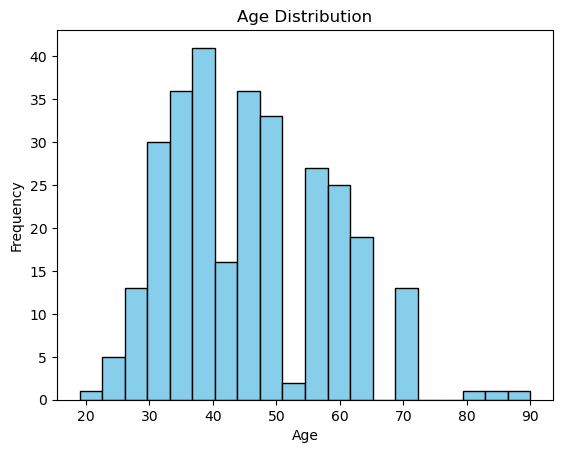

In [39]:
# Age distribution
df["Age"].plot(kind="hist", bins=20, color="skyblue", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()


[Text(0.5, 1.0, 'Gender-Based Distribution of Blood Pressure Levels')]

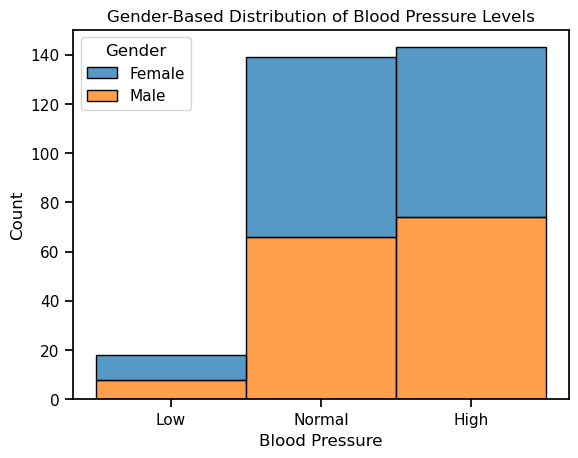

In [41]:
sns.set_context("notebook")
sns.histplot(data = df,x="Blood Pressure",hue = "Gender",multiple = "stack").set(title = "Gender-Based Distribution of Blood Pressure Levels")

In [43]:
num_col = df[columns].select_dtypes(include = ["int64","float64"])
corr_mat = num_col.corr()
print(corr_mat)

NameError: name 'columns' is not defined

In [45]:
sns.heatmap(corr_mat,annot =True, cmap = "Reds")


NameError: name 'corr_mat' is not defined

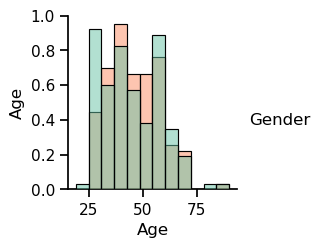

In [47]:
df.select_dtypes(include=["int64", "float64"]).columns
numeric_df = df.select_dtypes(include=["int64", "float64"])
plot_df = numeric_df.join(df["Gender"])

# Create pairplot
sns.pairplot(data=plot_df, hue="Gender", palette="Set2", diag_kind="hist")
plt.show()


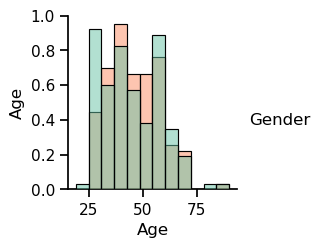

In [49]:

sns.pairplot(data = df,hue ="Gender",palette = "Set2",diag_kind = "hist")

<Axes: xlabel='Age', ylabel='Density'>

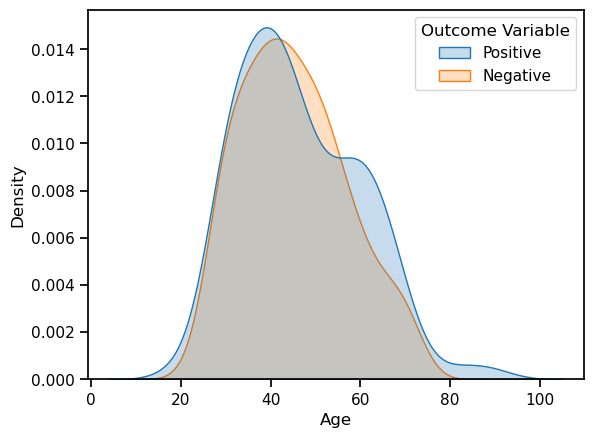

In [53]:
sns.kdeplot(data = df,x = "Age", hue = "Outcome Variable" , fill = True)


C:\Users\anant\AppData\Local\Temp\ipykernel_11964\409231130.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Gender", y="Age", palette=["dodgerblue", "orange"])


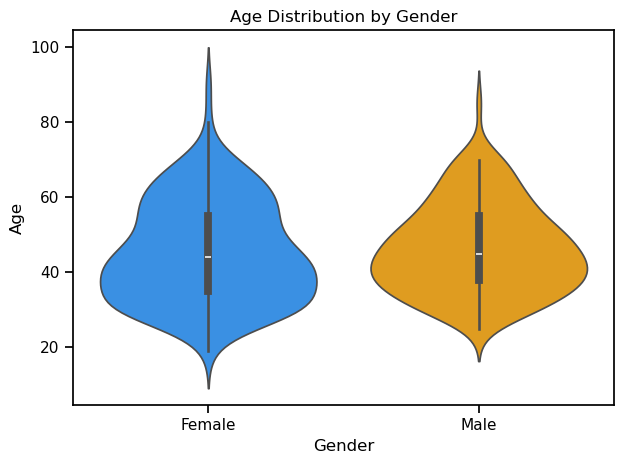

In [56]:
sns.violinplot(data=df, x="Gender", y="Age", palette=["dodgerblue", "orange"])
plt.title("Age Distribution by Gender")
plt.tight_layout()
plt.show()

C:\Users\vishn\AppData\Local\Temp\ipykernel_16260\1685751300.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["Gender", "Age Group", "Disease"]).size().reset_index(name="Count")
C:\Users\vishn\AppData\Local\Temp\ipykernel_16260\1685751300.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=filtered, x="Disease", y="Count", hue="Gender", ci=None)


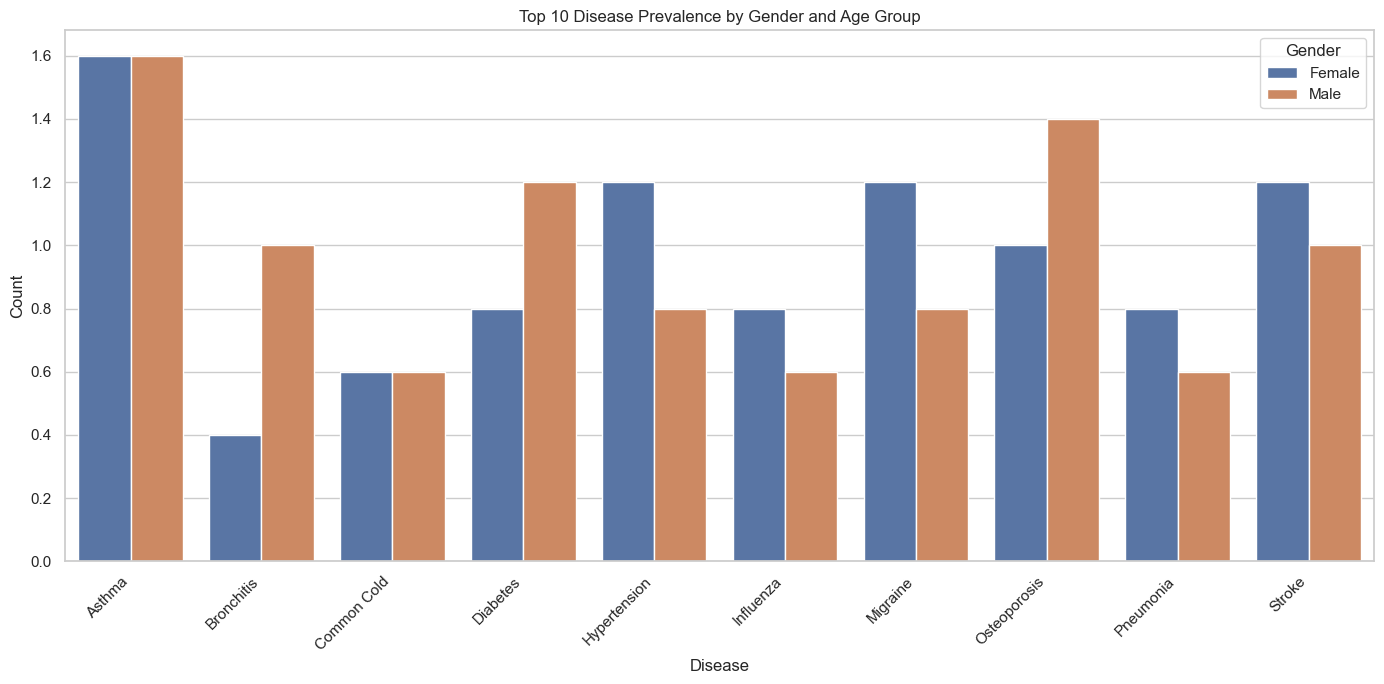